<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-ZapataGonzalez/Evaluacion2/ZapataGonzalez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np


from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
 # Configuración Estética Definitiva para Google Colab (Fuerza LaTeX real del sistema)
plt.rcParams.update({
    "text.usetex": True,                     # ¡ACTIVAMOS EL COMPILADOR REAL DE LATEX!
    "font.family": "serif",                  # Familia serif obligatoria
    "font.serif": ["Computer Modern Roman"], # Fuente académica por excelencia
    "text.latex.preamble": r"\usepackage[utf8]{inputenc} \usepackage[T1]{fontenc} \usepackage{amsmath}", # Soporte nativo para español
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Estética de guardado
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

print('Configuración de Fuentes Científicas con LaTeX Real OK')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 128 kB in 2s (51.3 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
d

In [2]:
!curl -L -o generar_datos.py \
https://raw.githubusercontent.com/manubastidas/programacionCientifica/main/Evaluacion2/generar_datos.py

!curl -L -o generar_enunciado.py \
https://raw.githubusercontent.com/manubastidas/programacionCientifica/main/Evaluacion2/generar_enunciado.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2468  100  2468    0     0   8995      0 --:--:-- --:--:-- --:--:--  9007
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  6601  100  6601    0     0  25213      0 --:--:-- --:--:-- --:--:-- 25291


In [3]:
!python generar_enunciado.py 3951
!python generar_datos.py 3951

Enunciado generado para cédula 3951: enunciado_3951.md
Los parámetros: K=25, iteraciones=3000, η=0.02, n=12/régimen, régimen foco=0, compresión 85%
Datos generados para cédula 3951: X=(36, 256), y=(36,), t=(256,)
Guardado en datos_3951.npz


In [4]:
!sudo apt-get install texlive-latex-recommended
!pip install pdflatex


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-latex-recommended is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 65 not upgraded.


In [5]:
!pip install --upgrade jax jaxlib

# Capa Fourier
El siguiente código contiene los resultados pedidos en la parte "capa fourier (15 pts)" de la rúbrica. (función de la capa de fourier, comparación con np.fft (evidencias matemáticas) y reporte de energía)

In [6]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import numpy as np
import matplotlib.pyplot as plt

# Configuración de parámetros establecidos por el enunciado
K = 25              # Número de frecuencias
hidden_dim = 2 * K  # 2K = 50 neuronas ocultas
n_features = 256    # Tamaño de la señal (t)
eta = 0.02          # Learning rate
iteraciones = 3000  # Número de iteraciones

# Carga de datos correspondientes a la cédula 3951
datos = np.load("datos_3951.npz")
X_train = jnp.array(datos['X'])
y_train = np.array(datos['y'])
t = jnp.array(datos['t'])

# 1. FUNCIÓN QUE CONSTRUYE LA CAPA FOURIER
def construir_capa_fourier(n_features=256, K=25):
    t_arr = jnp.linspace(0, 1, n_features, endpoint=False)
    W1_list = []
    for k in range(1, K + 1):
        W1_list.append(jnp.cos(2 * jnp.pi * k * t_arr) * jnp.sqrt(2.0 / n_features))
        W1_list.append(jnp.sin(2 * jnp.pi * k * t_arr) * jnp.sqrt(2.0 / n_features))
    return jnp.stack(W1_list, axis=0)

W1_fourier_init = construir_capa_fourier(n_features, K)

# ARQUITECTURA DE LA RED NEURONAL (Dos capas: W1 -> tanh -> W2)
def forward(params, x):
    phi = jnp.tanh(jnp.dot(params['W1'], x))
    x_hat = jnp.dot(params['W2'], phi)
    return x_hat

forward_batch = vmap(forward, in_axes=(None, 0))

@jit
def loss_fn(params, X):
    X_hat = forward_batch(params, X)
    return jnp.mean((X_hat - X) ** 2)

@jit
def update(params, X, lr):
    grads = grad(loss_fn)(params, X)
    updated_params = {
        'W1': params['W1'] - lr * grads['W1'],
        'W2': params['W2'] - lr * grads['W2']
    }
    return updated_params

#Reporte de datos
energia_media = float((X_train**2).mean())

print("CAPA FOURIER Y ENERGÍA")

print(f"Energía media del dataset ((X**2).mean()): {energia_media:.3f}\n")


# Poryeccion de W1
proyeccion = jnp.dot(W1_fourier_init, X_train[0])
mag_capa_k1 = jnp.sqrt(proyeccion[0]**2 + proyeccion[1]**2)

# FFT
fft_np = np.fft.rfft(X_train[0])
# Debemos multiplicar por el mismo factor de normalización que W1: sqrt(2/N)
factor_norm = np.sqrt(2.0 / n_features)
mag_fft_k1 = np.abs(fft_np[1]) * factor_norm

print("EVIDENCIA DE TRANSFORMADA DE FOURIER (k=1):")
print(f"Magnitud calculada por Capa W1:  {mag_capa_k1:.6f}")
print(f"Magnitud calculada por np.fft:   {mag_fft_k1:.6f}")
print(f"Diferencia absoluta:             {abs(mag_capa_k1 - mag_fft_k1):.2e}")


CAPA FOURIER Y ENERGÍA
Energía media del dataset ((X**2).mean()): 0.621

EVIDENCIA DE TRANSFORMADA DE FOURIER (k=1):
Magnitud calculada por Capa W1:  4.835033
Magnitud calculada por np.fft:   4.835033
Diferencia absoluta:             0.00e+00


# Entrenamiento, reconstrucción y comparación
El código a continuación contiene la red entrenada con las inicializaciones; Fourier y de manera aleatoria, el error reportado para cada caso y la medición de las iteraciones para bajar el error relativo.
Además genera las gráficas;
perdida L vs iteraciones para ambas iniciaciones superpuestas, el contraste del régimen especificacdo en las instruciones (μ=0.0) y para cada régimen la señal original y la reconstrucción.

Entrenando redes...
MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)
-> Inicialización Aleatoria: No alcanzó el umbral en 3000 iteraciones (Mínimo alcanzado: 0.775)
-> Inicialización de Fourier: No alcanzó el umbral en 3000 iteraciones (Mínimo alcanzado: 0.819)


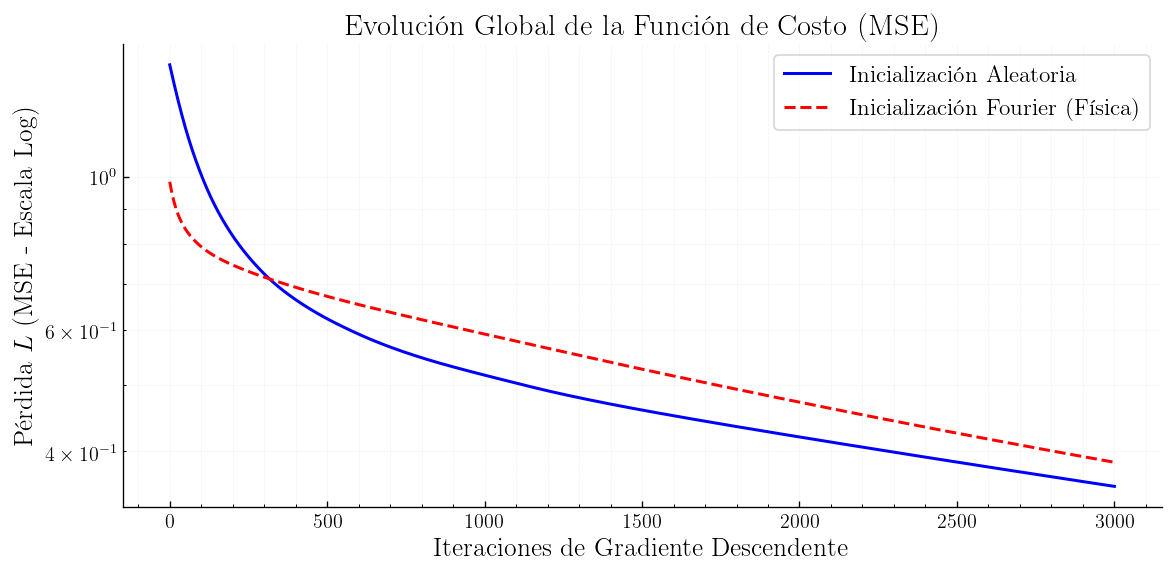

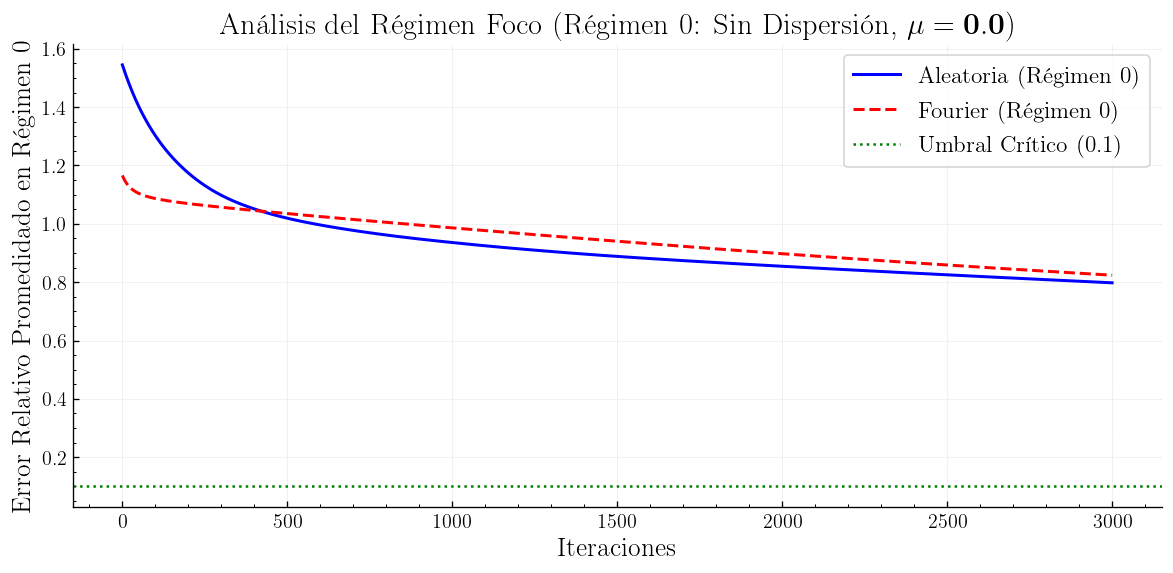

ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN
Régimen 0 (mu=0.0): Fourier Err = 0.9655 | Aleatorio Err = 0.8694
Régimen 1 (mu=5.0): Fourier Err = 0.7103 | Aleatorio Err = 0.7053
Régimen 2 (mu=15.0): Fourier Err = 0.9317 | Aleatorio Err = 0.8309




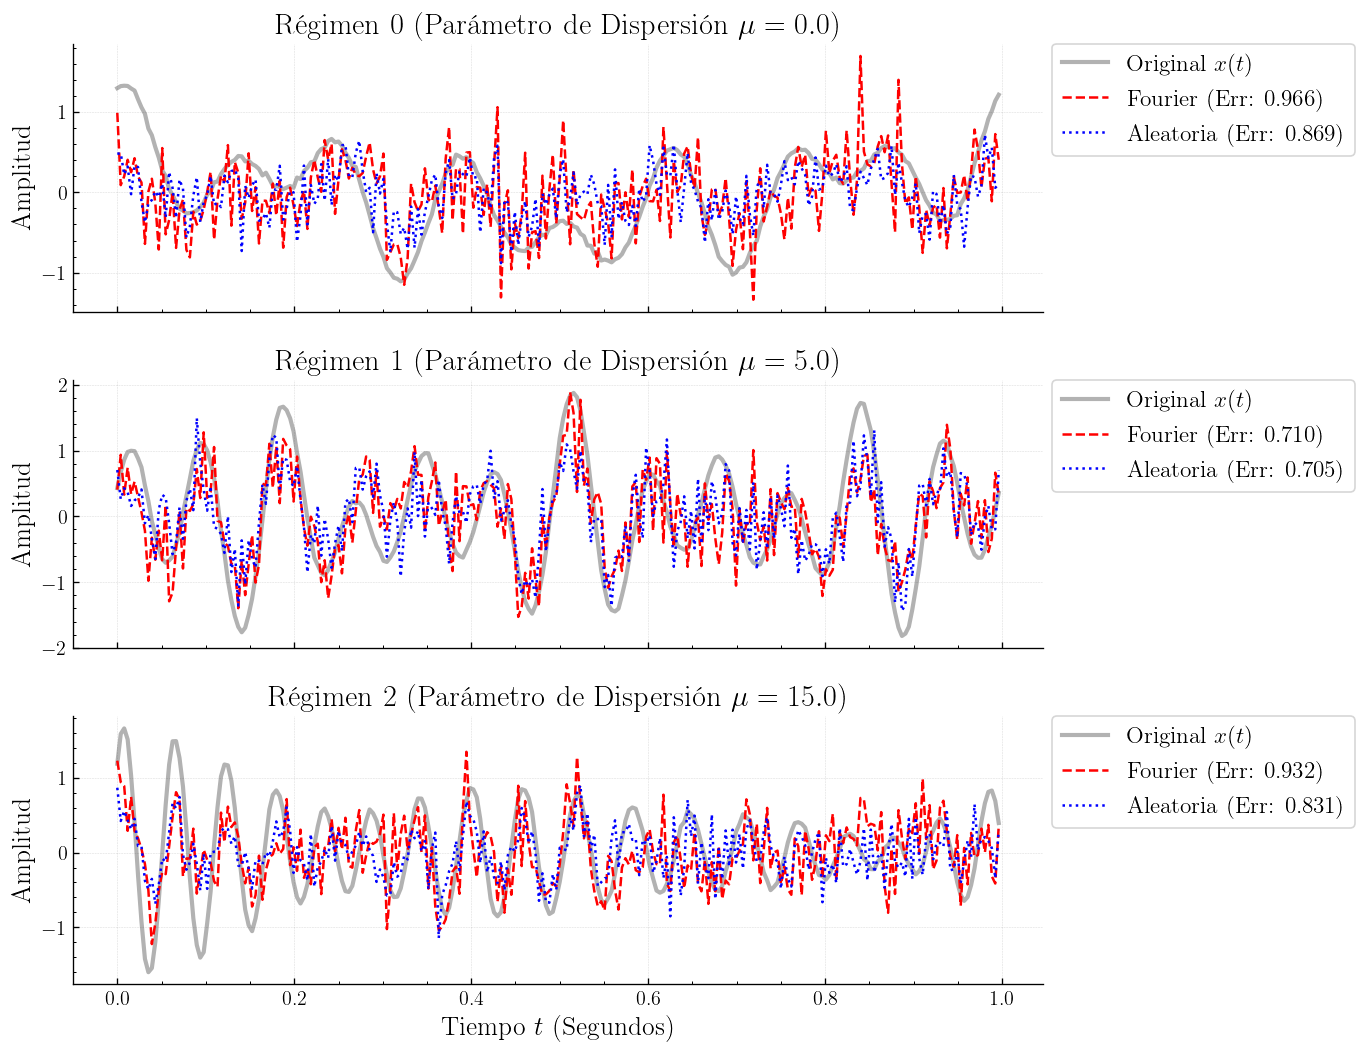

In [8]:
#Parte 1: iniciación y entrenamiento
# Semilla reproducible basada en tu ID
key = jax.random.PRNGKey(3951)
k1, k2 = jax.random.split(key)

params_rand = {
    'W1': jax.random.normal(k1, (hidden_dim, n_features)) * jnp.sqrt(2.0 / n_features),
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

params_four = {
    'W1': W1_fourier_init,
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

historial_loss_rand, historial_loss_four = [], []
historial_err_rand_global, historial_err_four_global = [], []
historial_err_rand_r0, historial_err_four_r0 = [], []
#error relativo
def calcular_error_relativo_lote(X_real, X_pred):
    norma_error = np.linalg.norm(X_pred - X_real, axis=1)
    norma_real = np.linalg.norm(X_real, axis=1)
    return norma_error / norma_real
params_rand = {
    'W1': jax.random.normal(k1, (hidden_dim, n_features)) * jnp.sqrt(2.0 / n_features),
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

params_four = {
    'W1': W1_fourier_init,
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

historial_loss_rand, historial_loss_four = [], []
historial_err_rand_global, historial_err_four_global = [], []
historial_err_rand_r0, historial_err_four_r0 = [], []
# Índice para Régimen 0 (Enfoque según instrucciones)
idx_regimen_foco = np.where(y_train == 0)[0]

p_rand = params_rand.copy()
p_four = params_four.copy()

print("Entrenando redes...")
for i in range(iteraciones + 1):
    p_rand = update(p_rand, X_train, eta)
    p_four = update(p_four, X_train, eta)

    loss_r = loss_fn(p_rand, X_train)
    loss_f = loss_fn(p_four, X_train)
    historial_loss_rand.append(loss_r)
    historial_loss_four.append(loss_f)

    x_hat_r_curr = np.array(forward_batch(p_rand, X_train))
    x_hat_f_curr = np.array(forward_batch(p_four, X_train))

    err_r_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_r_curr)
    err_f_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_f_curr)

    historial_err_rand_global.append(np.mean(err_r_individual))
    historial_err_four_global.append(np.mean(err_f_individual))

    historial_err_rand_r0.append(np.mean(err_r_individual[idx_regimen_foco]))
    historial_err_four_r0.append(np.mean(err_f_individual[idx_regimen_foco]))

# BÚSQUEDA DE UMBRAL
def buscar_iteracion_umbral(historial, umbral):
    for idx, val in enumerate(historial):
        if val < umbral: return f"{idx} iteraciones."
    return f"No alcanzó el umbral en 3000 iteraciones (Mínimo alcanzado: {min(historial):.3f})"


print("MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)")
print(f"-> Inicialización Aleatoria: {buscar_iteracion_umbral(historial_err_rand_global, 0.1)}")
print(f"-> Inicialización de Fourier: {buscar_iteracion_umbral(historial_err_four_global, 0.1)}")


# VISUALIZACIÓN

# A. Pérdida Global
plt.figure(figsize=(10, 5))
plt.plot(historial_loss_rand, 'b-', label=r'$\text{Inicialización Aleatoria}$', linewidth=1.8)
plt.plot(historial_loss_four, 'r--', label=r'$\text{Inicialización Fourier (Física)}$', linewidth=1.8)
plt.yscale('log')
plt.xlabel(r'$\text{Iteraciones de Gradiente Descendente}$')
plt.ylabel(r'$\text{Pérdida } L \text{ (MSE - Escala Log)}$')
plt.title(r'$\mathbf{\text{Evolución Global de la Función de Costo (MSE)}}$')
plt.grid(True, which="both", ls=":")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# B. Régimen 0 (Enfoque de las instrucciones)
plt.figure(figsize=(10, 5))
plt.plot(historial_err_rand_r0, 'b-', label=r'$\text{Aleatoria (Régimen 0)}$', linewidth=1.8)
plt.plot(historial_err_four_r0, 'r--', label=r'$\text{Fourier (Régimen 0)}$', linewidth=1.8)
plt.axhline(y=0.1, color='g', linestyle=':', label=r'$\text{Umbral Crítico (0.1)}$')
plt.xlabel(r'$\text{Iteraciones}$')
plt.ylabel(r'$\text{Error Relativo Promedidado en Régimen 0}$')
plt.title(r'$\mathbf{\text{Análisis del Régimen Foco (Régimen 0: Sin Dispersión, } \mu=0.0)}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# C. Reconstrucciones finales para cada régimen
X_hat_final_rand = forward_batch(p_rand, X_train)
X_hat_final_four = forward_batch(p_four, X_train)
valores_mu = {0: "0.0", 1: "5.0", 2: "15.0"}

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

print("ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN")

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0]
    err_f = np.linalg.norm(X_hat_final_four[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    err_r = np.linalg.norm(X_hat_final_rand[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    print(f"Régimen {reg} (mu={valores_mu[reg]}): Fourier Err = {err_f:.4f} | Aleatorio Err = {err_r:.4f}")

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.5)
    axs[reg].plot(t, X_hat_final_four[idx], 'r--', label=r'$\text{Fourier (Err: ' + f'{err_f:.3f}' + ')}$')
    axs[reg].plot(t, X_hat_final_rand[idx], 'b:', label=r'$\text{Aleatoria (Err: ' + f'{err_r:.3f}' + ')}$')

    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (Parámetro de Dispersión } \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.)
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.80)
print("\n")
plt.show()

# Compresión
Gráfica: error de reconstrucción vs número de coeficientes conservados. Primero para todos los coeficientes (de 1 a 50) con el 85% de energía señalado.
Ahora se sabe cuantos coeficientes bastan para ese umbral de energia y se grafica cada régimen con ese coeficientes y se compara con la señal original.

ANÁLISIS DE COMPRESIÓN 
Coeficientes mínimos necesarios para alcanzar el 85% de energía: 5
Porcentaje de compresión del espacio: 90.00%



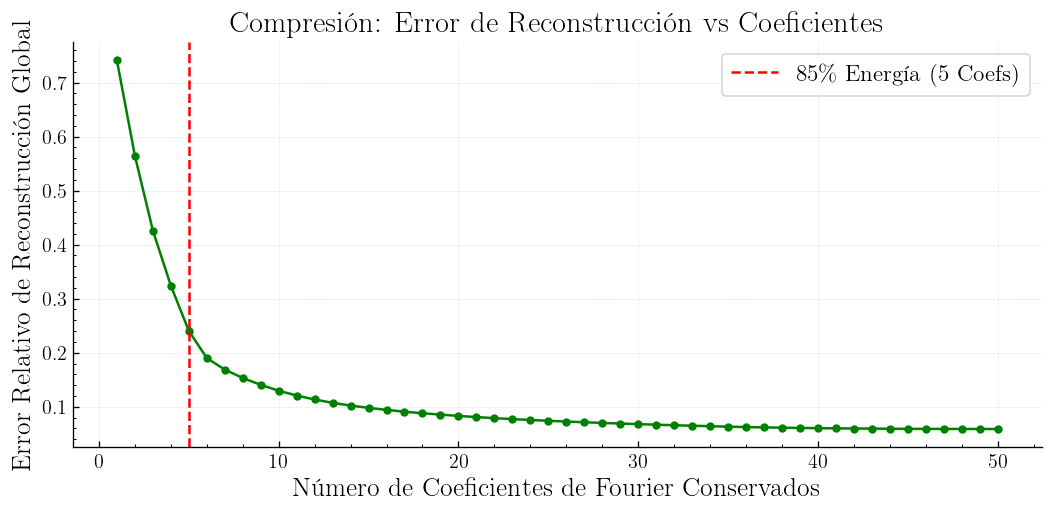

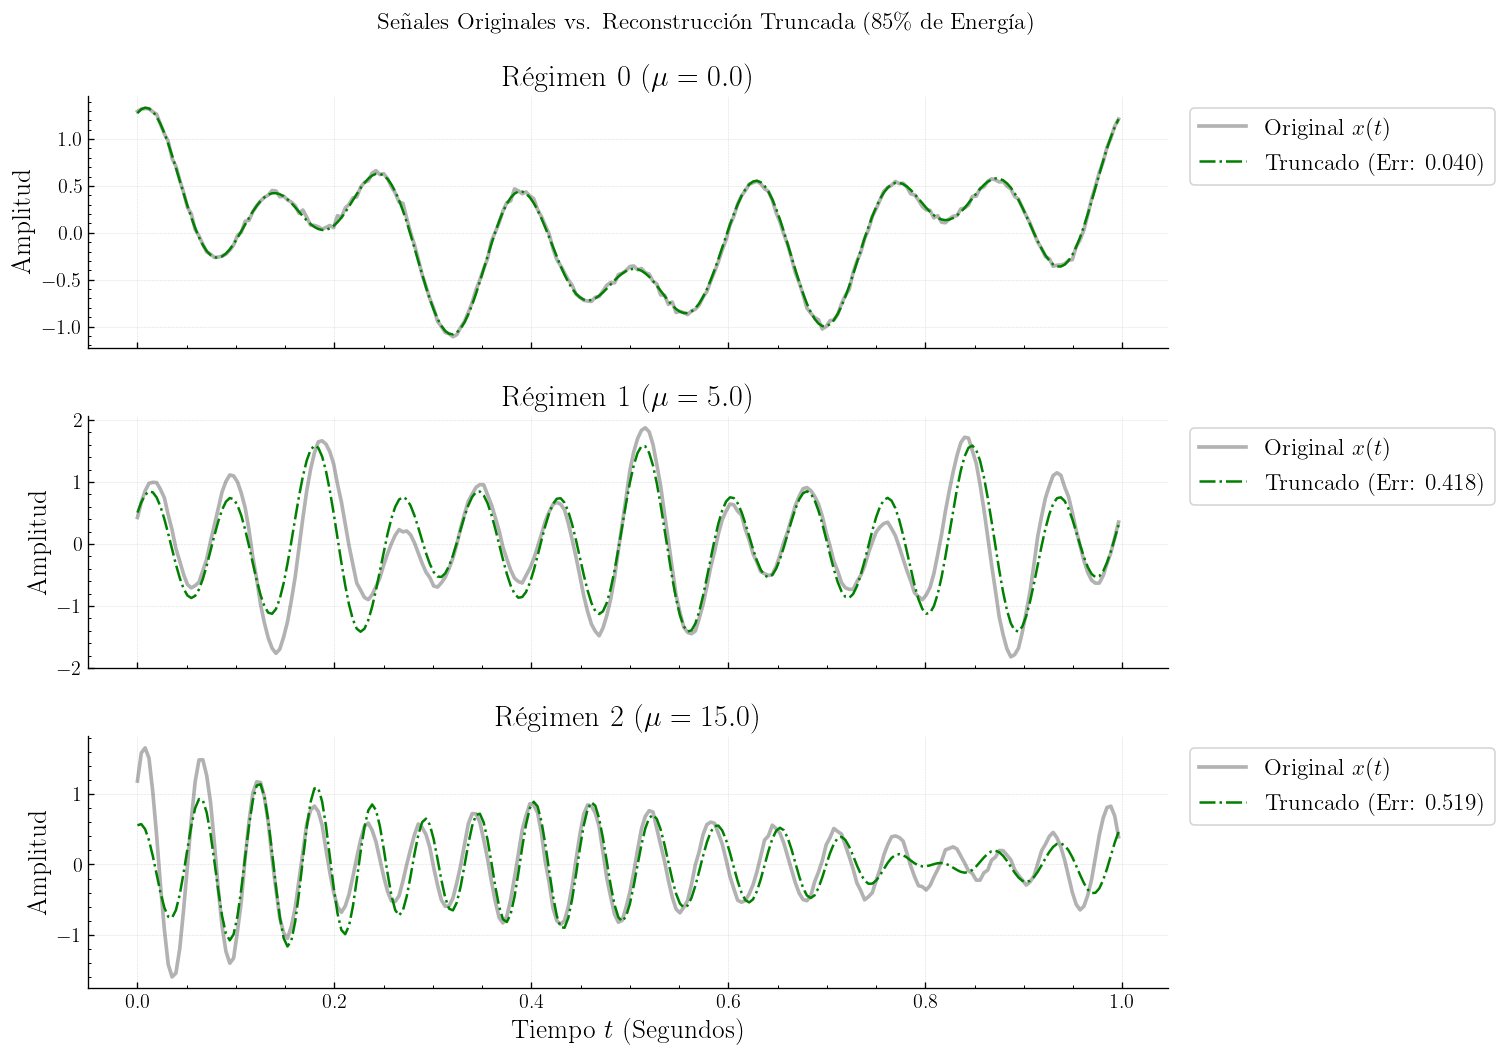

In [9]:
# Proyección de señales sobre la base compacta de Fourier
coeficientes_fourier = np.dot(np.array(X_train), W1_fourier_init.T)
energia_componentes = coeficientes_fourier ** 2

# Ordenar energías de mayor a menor por cada señal
energia_ordenada = np.sort(energia_componentes, axis=1)[:, ::-1]
energia_total = np.sum(energia_ordenada, axis=1, keepdims=True)
energia_acumulada_relativa = np.cumsum(energia_ordenada, axis=1) / energia_total

# Determinar componentes exactas para superar el 85% de la energía
UMBRAL_ENERGIA = 0.85
componentes_por_senal = np.argmax(energia_acumulada_relativa >= UMBRAL_ENERGIA, axis=1) + 1
componentes_necesarias_promedio = int(np.ceil(np.mean(componentes_por_senal)))

print("ANÁLISIS DE COMPRESIÓN ")

print(f"Coeficientes mínimos necesarios para alcanzar el 85% de energía: {componentes_necesarias_promedio}")
print(f"Porcentaje de compresión del espacio: {((1 - componentes_necesarias_promedio/hidden_dim)*100):.2f}%\n")

# Reconstrucción truncada
X_train_reconstruido_fourier = np.zeros_like(X_train)
base_fourier_pinv = np.linalg.pinv(W1_fourier_init.T)

for idx in range(X_train.shape[0]):
    coefs = coeficientes_fourier[idx].copy()
    indices_baja_energia = np.argsort(energia_componentes[idx])[::-1][componentes_necesarias_promedio:]
    coefs[indices_baja_energia] = 0.0
    X_train_reconstruido_fourier[idx] = np.dot(coefs, base_fourier_pinv)

# Evaluación paramétrica de error vs coeficientes para la curva verde
errores_por_coeficiente = []
for k_coef in range(1, hidden_dim + 1):
    err_acum = []
    for idx in range(X_train.shape[0]):
        coefs = coeficientes_fourier[idx].copy()
        indices_baja_energia = np.argsort(energia_componentes[idx])[::-1][k_coef:]
        coefs[indices_baja_energia] = 0.0
        rec = np.dot(coefs, base_fourier_pinv)
        err_acum.append(np.linalg.norm(rec - X_train[idx]) / np.linalg.norm(X_train[idx]))
    errores_por_coeficiente.append(np.mean(err_acum))

# GRÁFICA DE COMPRESIÓN MÍNIMA EXIGIDA
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, hidden_dim + 1), errores_por_coeficiente, 'g-o', markersize=4)
plt.axvline(x=componentes_necesarias_promedio, color='r', linestyle='--',
            label=r'$85\%\text{ Energía (' + str(componentes_necesarias_promedio) + r' Coefs)}$')
plt.xlabel(r'$\text{Número de Coeficientes de Fourier Conservados}$')
plt.ylabel(r'$\text{Error Relativo de Reconstrucción Global}$')
plt.title(r'$\mathbf{\text{Compresión: Error de Reconstrucción vs Coeficientes}}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Visualización Temporal de la Señal Truncada por Régimen
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(r'$\mathbf{\text{Señales Originales vs. Reconstrucción Truncada (85\% de Energía)}}$', fontsize=14, y=0.98)

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0]
    err_trunc = np.linalg.norm(X_train_reconstruido_fourier[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.2)
    axs[reg].plot(t, X_train_reconstruido_fourier[idx], 'g-.', label=r'$\text{Truncado (Err: ' + f'{err_trunc:.3f}' + ')}$')
    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (} \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.show()

# Experimentación con los hiperparámetros
Con 50 neuronas, el learning rate de 0.02 y 3000 iteraciones ninugna de las dos inicializaciones disminuye el error relativo por debajo de 0.1, como para la práctica estos hiperparámetros son fijos, se van a realizar unos experimentos cambiando sus  valores como ejercicio para aprender a mejorar los resultados con estas 3 combinaciones.


# Cambio en las iteraciones
Aumentar las iteraciones le da más tiempo a la red de entrenarse.

Entrenando redes...
MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)
-> Inicialización Aleatoria: No alcanzó el umbral en 8000 iteraciones (Mínimo alcanzado: 0.568)
-> Inicialización de Fourier: No alcanzó el umbral en 8000 iteraciones (Mínimo alcanzado: 0.567)


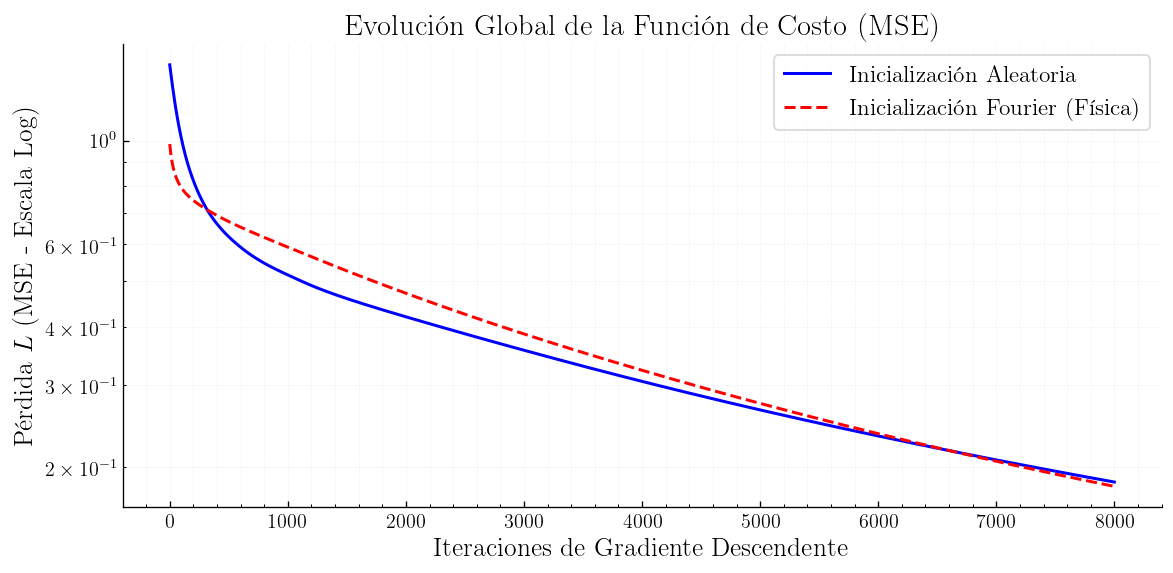

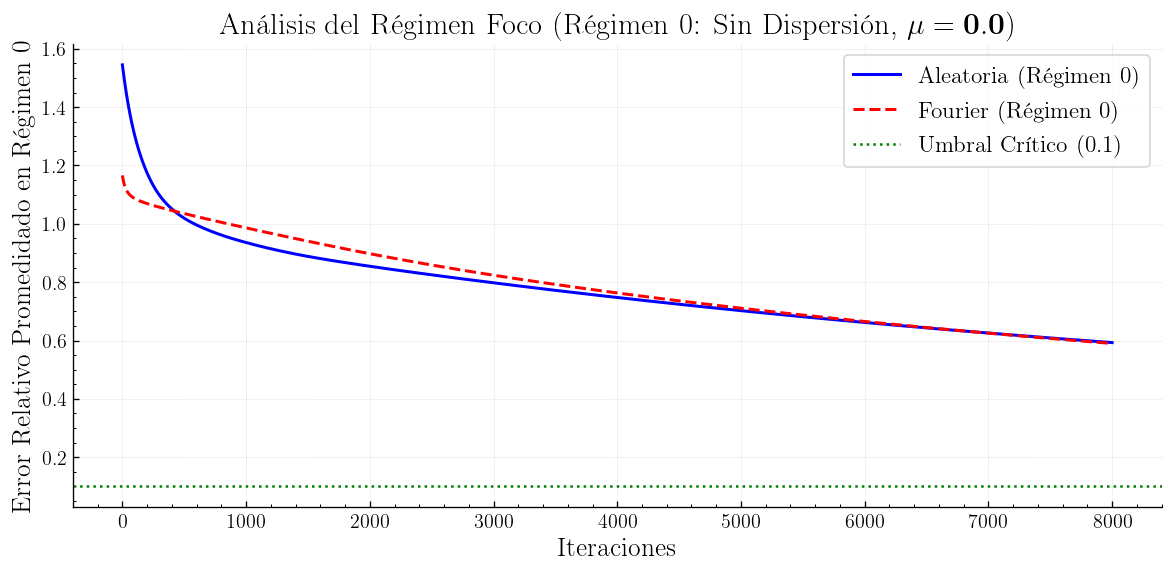

ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN
Régimen 0 (mu=0.0): Fourier Err = 0.7279 | Aleatorio Err = 0.7293
Régimen 1 (mu=5.0): Fourier Err = 0.4955 | Aleatorio Err = 0.4786
Régimen 2 (mu=15.0): Fourier Err = 0.7118 | Aleatorio Err = 0.6740




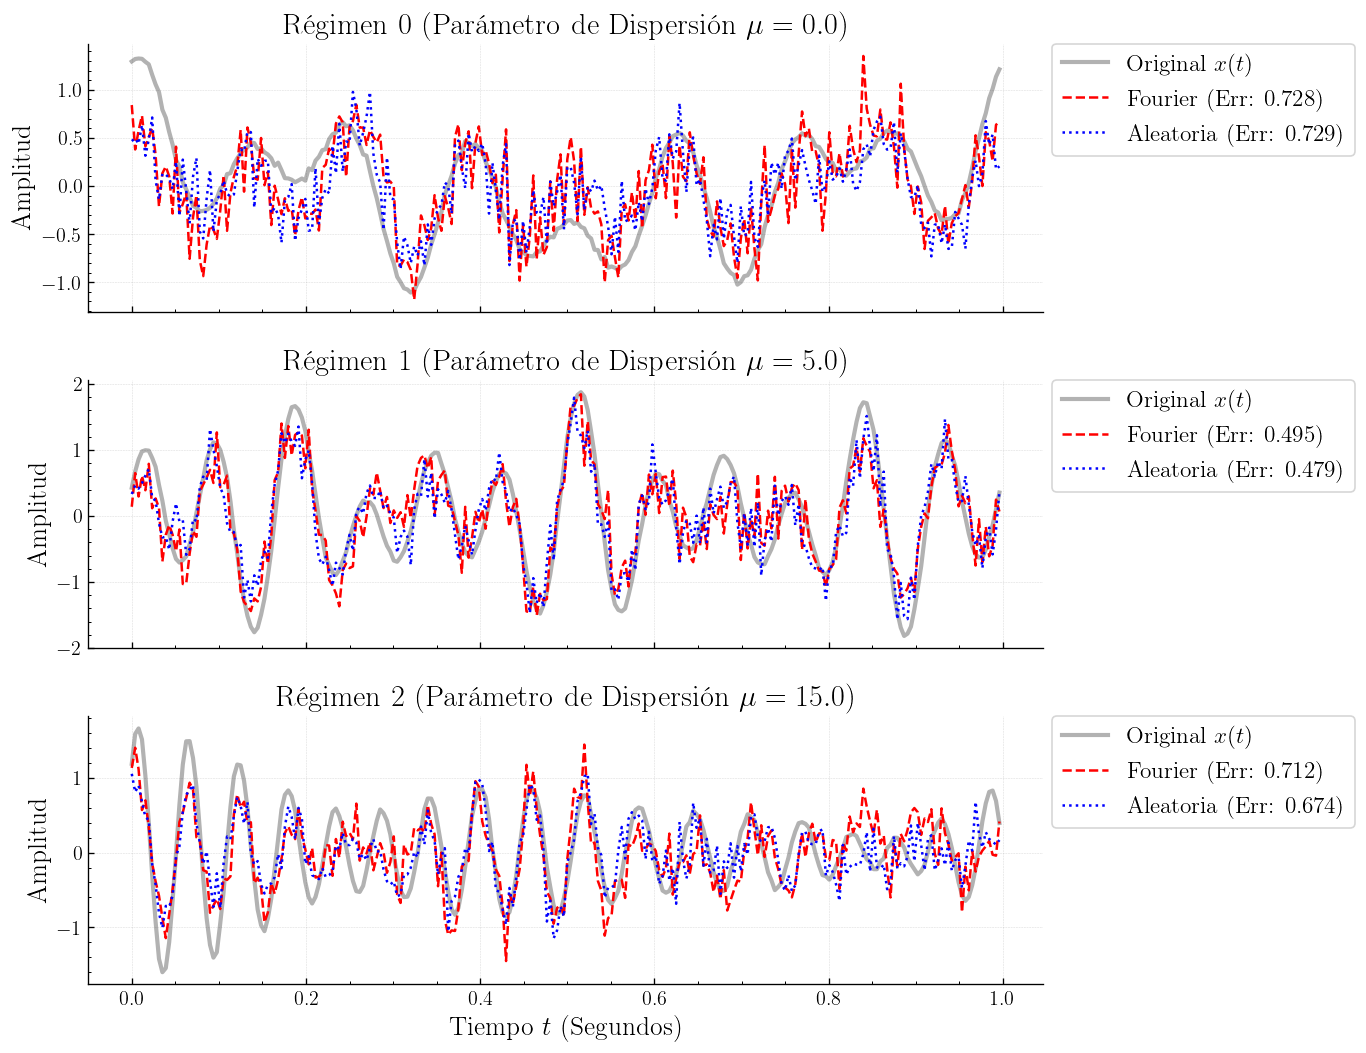

In [10]:
#AJUSTE DE HIPERPARÁMETROS PARA EXPERIMENTAR
K_exp = 25              # Aumenta esto para dar más capacidad (hidden_dim = 2 * K)
eta_exp = 0.02
iteraciones_exp = 8000  # Despues de probar indvidualmente esta fue la mejor cantidad

# Actualizamos los valores que usará el entrenamiento
hidden_dim = 2 * K_exp
eta = eta_exp
iteraciones = iteraciones_exp
# Codigo previamente utilizado para el entrenamiento
#Parte 1: iniciación y entrenamiento

# Semilla reproducible basada en tu ID
key = jax.random.PRNGKey(3951)
k1, k2 = jax.random.split(key)
#Error relativo
def calcular_error_relativo_lote(X_real, X_pred):
    norma_error = np.linalg.norm(X_pred - X_real, axis=1)
    norma_real = np.linalg.norm(X_real, axis=1)
    return norma_error / norma_real
params_rand = {
    'W1': jax.random.normal(k1, (hidden_dim, n_features)) * jnp.sqrt(2.0 / n_features),
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

params_four = {
    'W1': W1_fourier_init,
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

historial_loss_rand, historial_loss_four = [], []
historial_err_rand_global, historial_err_four_global = [], []
historial_err_rand_r0, historial_err_four_r0 = [], []

# Índice para Régimen 0 (Enfoque según instrucciones)
idx_regimen_foco = np.where(y_train == 0)[0]

p_rand = params_rand.copy()
p_four = params_four.copy()

print("Entrenando redes...")
for i in range(iteraciones + 1):
    p_rand = update(p_rand, X_train, eta)
    p_four = update(p_four, X_train, eta)

    loss_r = loss_fn(p_rand, X_train)
    loss_f = loss_fn(p_four, X_train)
    historial_loss_rand.append(loss_r)
    historial_loss_four.append(loss_f)

    x_hat_r_curr = np.array(forward_batch(p_rand, X_train))
    x_hat_f_curr = np.array(forward_batch(p_four, X_train))

    err_r_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_r_curr)
    err_f_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_f_curr)

    historial_err_rand_global.append(np.mean(err_r_individual))
    historial_err_four_global.append(np.mean(err_f_individual))

    historial_err_rand_r0.append(np.mean(err_r_individual[idx_regimen_foco]))
    historial_err_four_r0.append(np.mean(err_f_individual[idx_regimen_foco]))

# BÚSQUEDA DE UMBRAL
def buscar_iteracion_umbral(historial, umbral):
    for idx, val in enumerate(historial):
        if val < umbral: return f"{idx} iteraciones."
    return f"No alcanzó el umbral en {iteraciones} iteraciones (Mínimo alcanzado: {min(historial):.3f})"


print("MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)")
print(f"-> Inicialización Aleatoria: {buscar_iteracion_umbral(historial_err_rand_global, 0.1)}")
print(f"-> Inicialización de Fourier: {buscar_iteracion_umbral(historial_err_four_global, 0.1)}")


# VISUALIZACIÓN

# A. Pérdida Global
plt.figure(figsize=(10, 5))
plt.plot(historial_loss_rand, 'b-', label=r'$\text{Inicialización Aleatoria}$', linewidth=1.8)
plt.plot(historial_loss_four, 'r--', label=r'$\text{Inicialización Fourier (Física)}$', linewidth=1.8)
plt.yscale('log')
plt.xlabel(r'$\text{Iteraciones de Gradiente Descendente}$')
plt.ylabel(r'$\text{Pérdida } L \text{ (MSE - Escala Log)}$')
plt.title(r'$\mathbf{\text{Evolución Global de la Función de Costo (MSE)}}$')
plt.grid(True, which="both", ls=":")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# B. Régimen 0 (Enfoque de las instrucciones)
plt.figure(figsize=(10, 5))
plt.plot(historial_err_rand_r0, 'b-', label=r'$\text{Aleatoria (Régimen 0)}$', linewidth=1.8)
plt.plot(historial_err_four_r0, 'r--', label=r'$\text{Fourier (Régimen 0)}$', linewidth=1.8)
plt.axhline(y=0.1, color='g', linestyle=':', label=r'$\text{Umbral Crítico (0.1)}$')
plt.xlabel(r'$\text{Iteraciones}$')
plt.ylabel(r'$\text{Error Relativo Promedidado en Régimen 0}$')
plt.title(r'$\mathbf{\text{Análisis del Régimen Foco (Régimen 0: Sin Dispersión, } \mu=0.0)}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# C. Reconstrucciones finales para cada régimen
X_hat_final_rand = forward_batch(p_rand, X_train)
X_hat_final_four = forward_batch(p_four, X_train)
valores_mu = {0: "0.0", 1: "5.0", 2: "15.0"}

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

print("ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN")

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0]
    err_f = np.linalg.norm(X_hat_final_four[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    err_r = np.linalg.norm(X_hat_final_rand[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    print(f"Régimen {reg} (mu={valores_mu[reg]}): Fourier Err = {err_f:.4f} | Aleatorio Err = {err_r:.4f}")

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.5)
    axs[reg].plot(t, X_hat_final_four[idx], 'r--', label=r'$\text{Fourier (Err: ' + f'{err_f:.3f}' + ')}$')
    axs[reg].plot(t, X_hat_final_rand[idx], 'b:', label=r'$\text{Aleatoria (Err: ' + f'{err_r:.3f}' + ')}$')

    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (Parámetro de Dispersión } \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.)
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.80)
print("\n")
plt.show()

# Cambio de capacidad de la red (neuronas)
Se puede observar que el cambio del código anterior disminuye el error y la ventaja que tenia la transformada de Fourier se pierde, pero el modelo sigue aprendiendo porque la evolución global del costo no se vuelve errática, ahora se va a cambiar la cantidad de neuronas para ver hasta donde se puede mejorar el error.

Entrenando redes...
MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)
-> Inicialización Aleatoria: No alcanzó el umbral en 8000 iteraciones (Mínimo alcanzado: 0.317)
-> Inicialización de Fourier: No alcanzó el umbral en 8000 iteraciones (Mínimo alcanzado: 0.332)


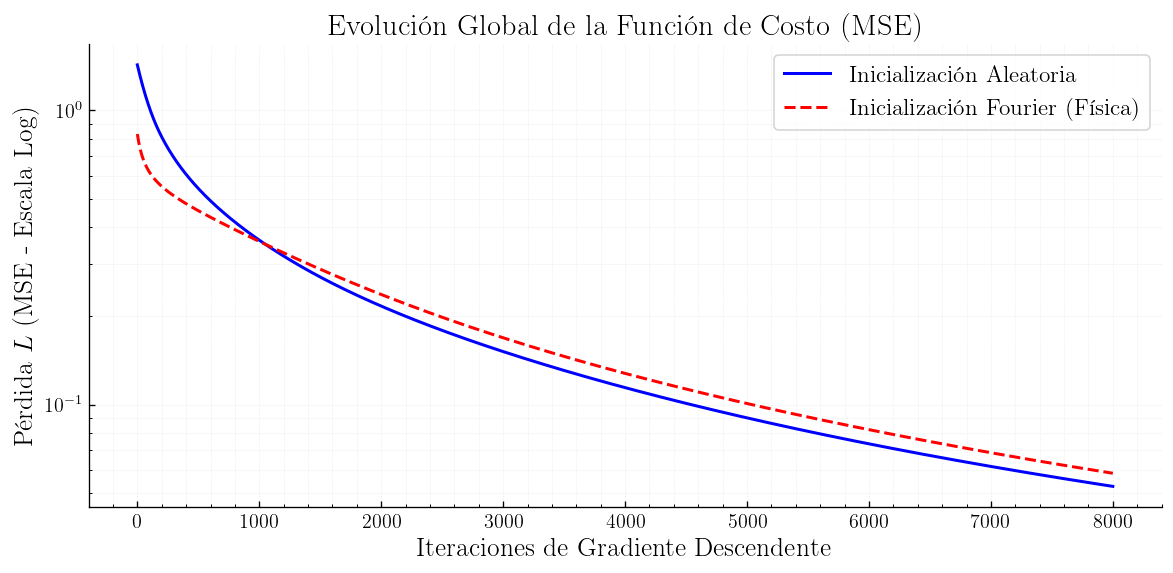

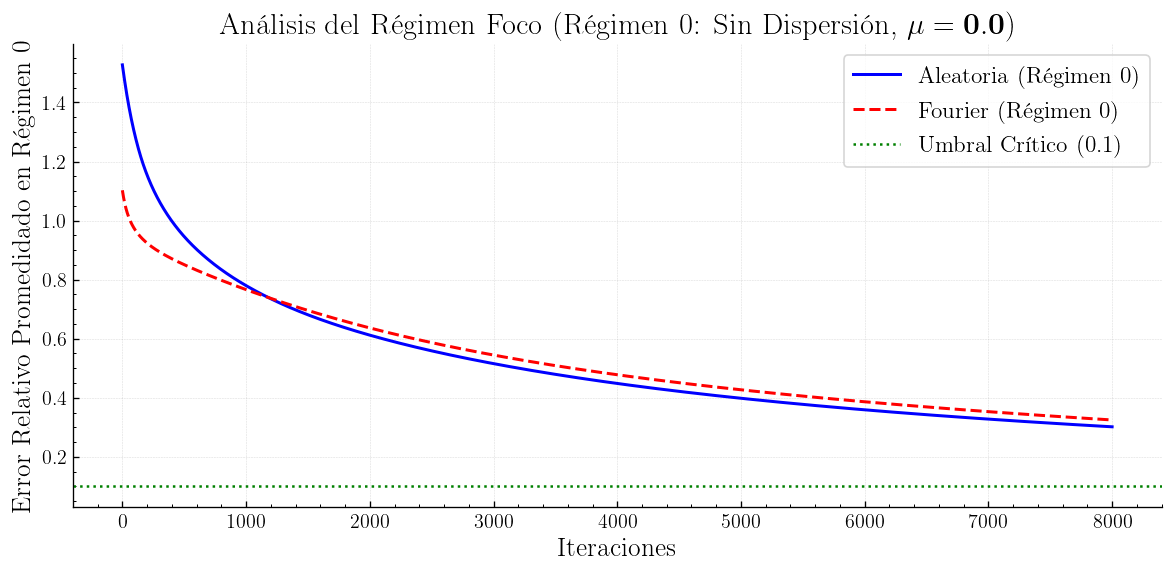

ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN
Régimen 0 (mu=0.0): Fourier Err = 0.4840 | Aleatorio Err = 0.4625
Régimen 1 (mu=5.0): Fourier Err = 0.2609 | Aleatorio Err = 0.2413
Régimen 2 (mu=15.0): Fourier Err = 0.4041 | Aleatorio Err = 0.4240




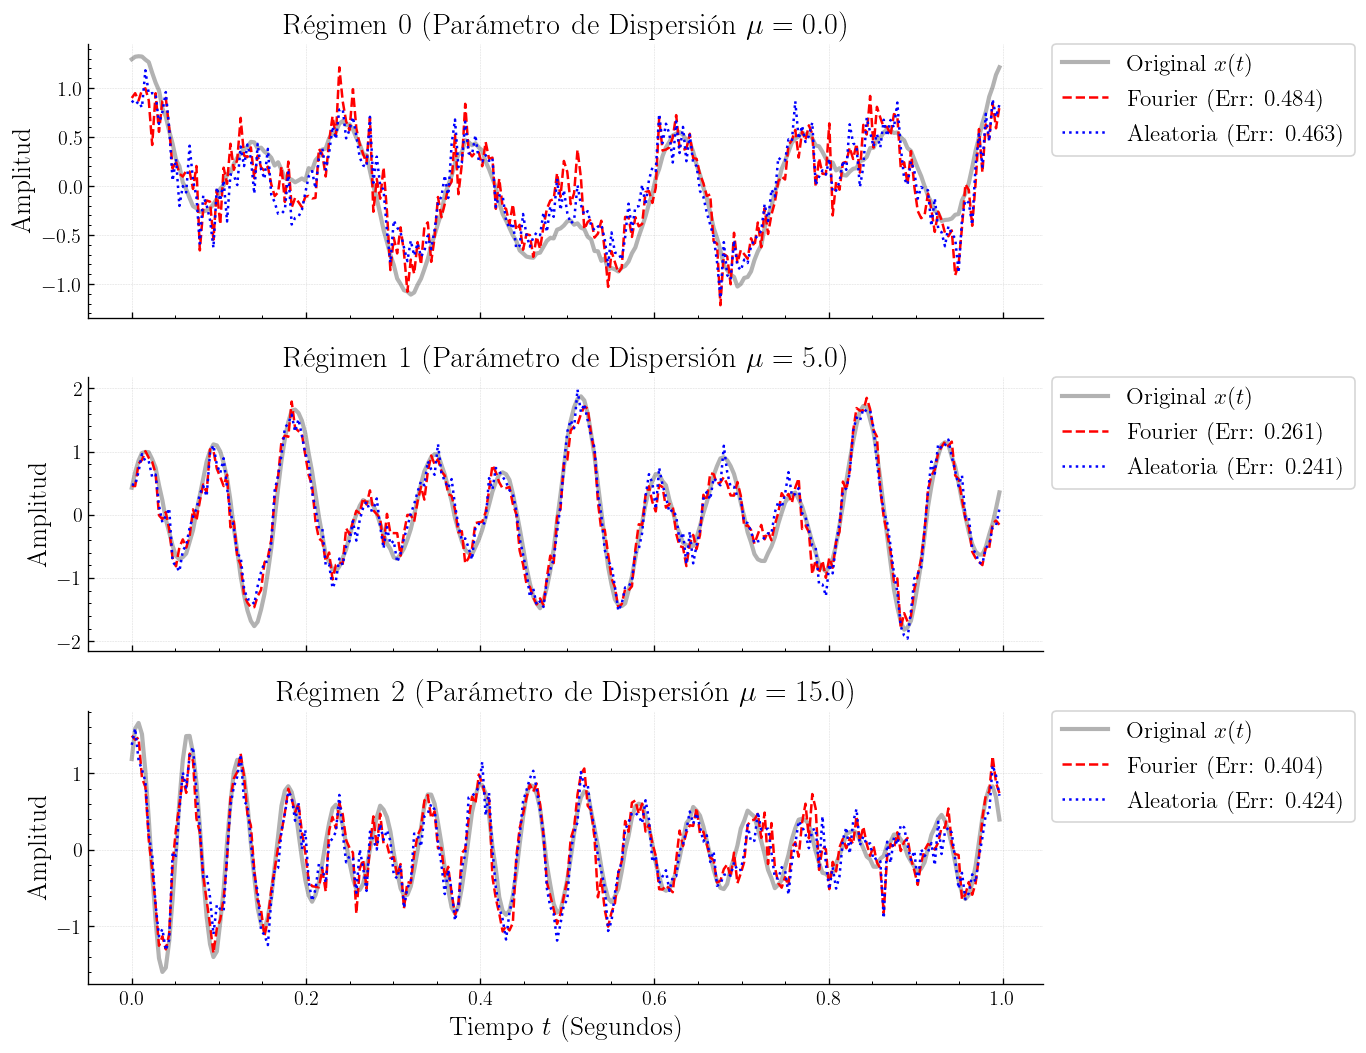

In [11]:
#AJUSTE DE HIPERPARÁMETROS PARA EXPERIMENTAR
K_exp = 50              # Aumenta esto para dar más capacidad (hidden_dim = 2 * K)
eta_exp = 0.02          # Prueba con 0.05, 0.01, 0.005
iteraciones_exp = 8000  # Despues de probar indvidualmente esta fue la mejor cantidad

# Actualizamos los valores que usará el entrenamiento
hidden_dim = 2 * K_exp
eta = eta_exp
iteraciones = iteraciones_exp

# Re-calculamos W1_fourier_init with the new K_exp
W1_fourier_init = construir_capa_fourier(n_features, K_exp)

# Codigo previamente utilizado para el entrenamiento
#Parte 1: iniciación y entrenamiento

# Semilla reproducible basada en tu ID
key = jax.random.PRNGKey(3951)
k1, k2 = jax.random.split(key)
#Error relativo
def calcular_error_relativo_lote(X_real, X_pred):
    norma_error = np.linalg.norm(X_pred - X_real, axis=1)
    norma_real = np.linalg.norm(X_real, axis=1)
    return norma_error / norma_real
params_rand = {
    'W1': jax.random.normal(k1, (hidden_dim, n_features)) * jnp.sqrt(2.0 / n_features),
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

params_four = {
    'W1': W1_fourier_init,
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

historial_loss_rand, historial_loss_four = [], []
historial_err_rand_global, historial_err_four_global = [], []
historial_err_rand_r0, historial_err_four_r0 = [], []

# Índice para Régimen 0 (Enfoque según instrucciones)
idx_regimen_foco = np.where(y_train == 0)[0]

p_rand = params_rand.copy()
p_four = params_four.copy()

print("Entrenando redes...")
for i in range(iteraciones + 1):
    p_rand = update(p_rand, X_train, eta)
    p_four = update(p_four, X_train, eta)

    loss_r = loss_fn(p_rand, X_train)
    loss_f = loss_fn(p_four, X_train)
    historial_loss_rand.append(loss_r)
    historial_loss_four.append(loss_f)

    x_hat_r_curr = np.array(forward_batch(p_rand, X_train))
    x_hat_f_curr = np.array(forward_batch(p_four, X_train))

    err_r_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_r_curr)
    err_f_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_f_curr)

    historial_err_rand_global.append(np.mean(err_r_individual))
    historial_err_four_global.append(np.mean(err_f_individual))

    historial_err_rand_r0.append(np.mean(err_r_individual[idx_regimen_foco]))
    historial_err_four_r0.append(np.mean(err_f_individual[idx_regimen_foco]))

# BÚSQUEDA DE UMBRAL
def buscar_iteracion_umbral(historial, umbral):
    for idx, val in enumerate(historial):
        if val < umbral: return f"{idx} iteraciones."
    return f"No alcanzó el umbral en {iteraciones} iteraciones (Mínimo alcanzado: {min(historial):.3f})"


print("MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)")
print(f"-> Inicialización Aleatoria: {buscar_iteracion_umbral(historial_err_rand_global, 0.1)}")
print(f"-> Inicialización de Fourier: {buscar_iteracion_umbral(historial_err_four_global, 0.1)}")


# VISUALIZACIÓN

# A. Pérdida Global
plt.figure(figsize=(10, 5))
plt.plot(historial_loss_rand, 'b-', label=r'$\text{Inicialización Aleatoria}$', linewidth=1.8)
plt.plot(historial_loss_four, 'r--', label=r'$\text{Inicialización Fourier (Física)}$', linewidth=1.8)
plt.yscale('log')
plt.xlabel(r'$\text{Iteraciones de Gradiente Descendente}$',)
plt.ylabel(r'$\text{Pérdida } L \text{ (MSE - Escala Log)}$')
plt.title(r'$\mathbf{\text{Evolución Global de la Función de Costo (MSE)}}$',)
plt.grid(True, which="both", ls=":")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# B. Régimen 0 (Enfoque de las instrucciones)
plt.figure(figsize=(10, 5))
plt.plot(historial_err_rand_r0, 'b-', label=r'$\text{Aleatoria (Régimen 0)}$', linewidth=1.8)
plt.plot(historial_err_four_r0, 'r--', label=r'$\text{Fourier (Régimen 0)}$', linewidth=1.8)
plt.axhline(y=0.1, color='g', linestyle=':', label=r'$\text{Umbral Crítico (0.1)}$')
plt.xlabel(r'$\text{Iteraciones}$')
plt.ylabel(r'$\text{Error Relativo Promedidado en Régimen 0}$')
plt.title(r'$\mathbf{\text{Análisis del Régimen Foco (Régimen 0: Sin Dispersión, } \mu=0.0)}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# C. Reconstrucciones finales para cada régimen
X_hat_final_rand = forward_batch(p_rand, X_train)
X_hat_final_four = forward_batch(p_four, X_train)
valores_mu = {0: "0.0", 1: "5.0", 2: "15.0"}

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

print("ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN")

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0]
    err_f = np.linalg.norm(X_hat_final_four[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    err_r = np.linalg.norm(X_hat_final_rand[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    print(f"Régimen {reg} (mu={valores_mu[reg]}): Fourier Err = {err_f:.4f} | Aleatorio Err = {err_r:.4f}")

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.5)
    axs[reg].plot(t, X_hat_final_four[idx], 'r--', label=r'$\text{Fourier (Err: ' + f'{err_f:.3f}' + ')}$')
    axs[reg].plot(t, X_hat_final_rand[idx], 'b:', label=r'$\text{Aleatoria (Err: ' + f'{err_r:.3f}' + ')}$')

    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (Parámetro de Dispersión } \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.)
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.80)
print("\n")
plt.show()

# Cambio del learning rate
Vimos que el error disminuyó al utilizar el doble de neuronas, los régimenes 1 y 2 se hacercan más a los valores originales y Fourier recuperó un poco su ventaja.
Finalmente se va a camibar la tasa de aprendizaje, al tener más neuronas una tasa grande puede impedir una mejor convergencia.  

Entrenando redes...
MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)
-> Inicialización Aleatoria: No alcanzó el umbral en 8000 iteraciones (Mínimo alcanzado: 0.326)
-> Inicialización de Fourier: No alcanzó el umbral en 8000 iteraciones (Mínimo alcanzado: 0.342)


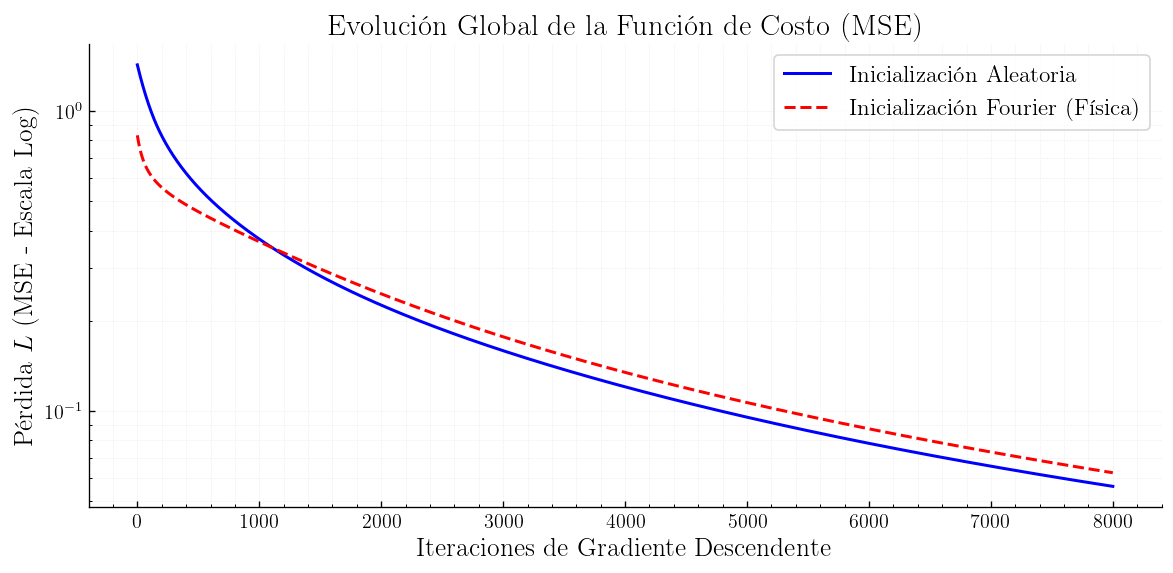

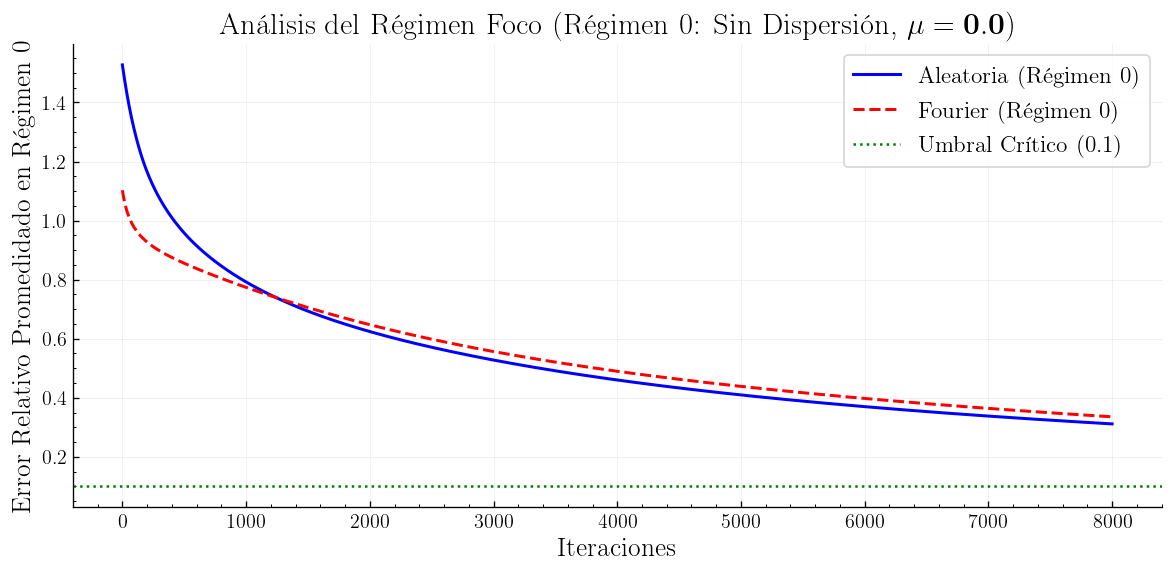

ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN
Régimen 0 (mu=0.0): Fourier Err = 0.4949 | Aleatorio Err = 0.4710
Régimen 1 (mu=5.0): Fourier Err = 0.2724 | Aleatorio Err = 0.2529
Régimen 2 (mu=15.0): Fourier Err = 0.4110 | Aleatorio Err = 0.4337




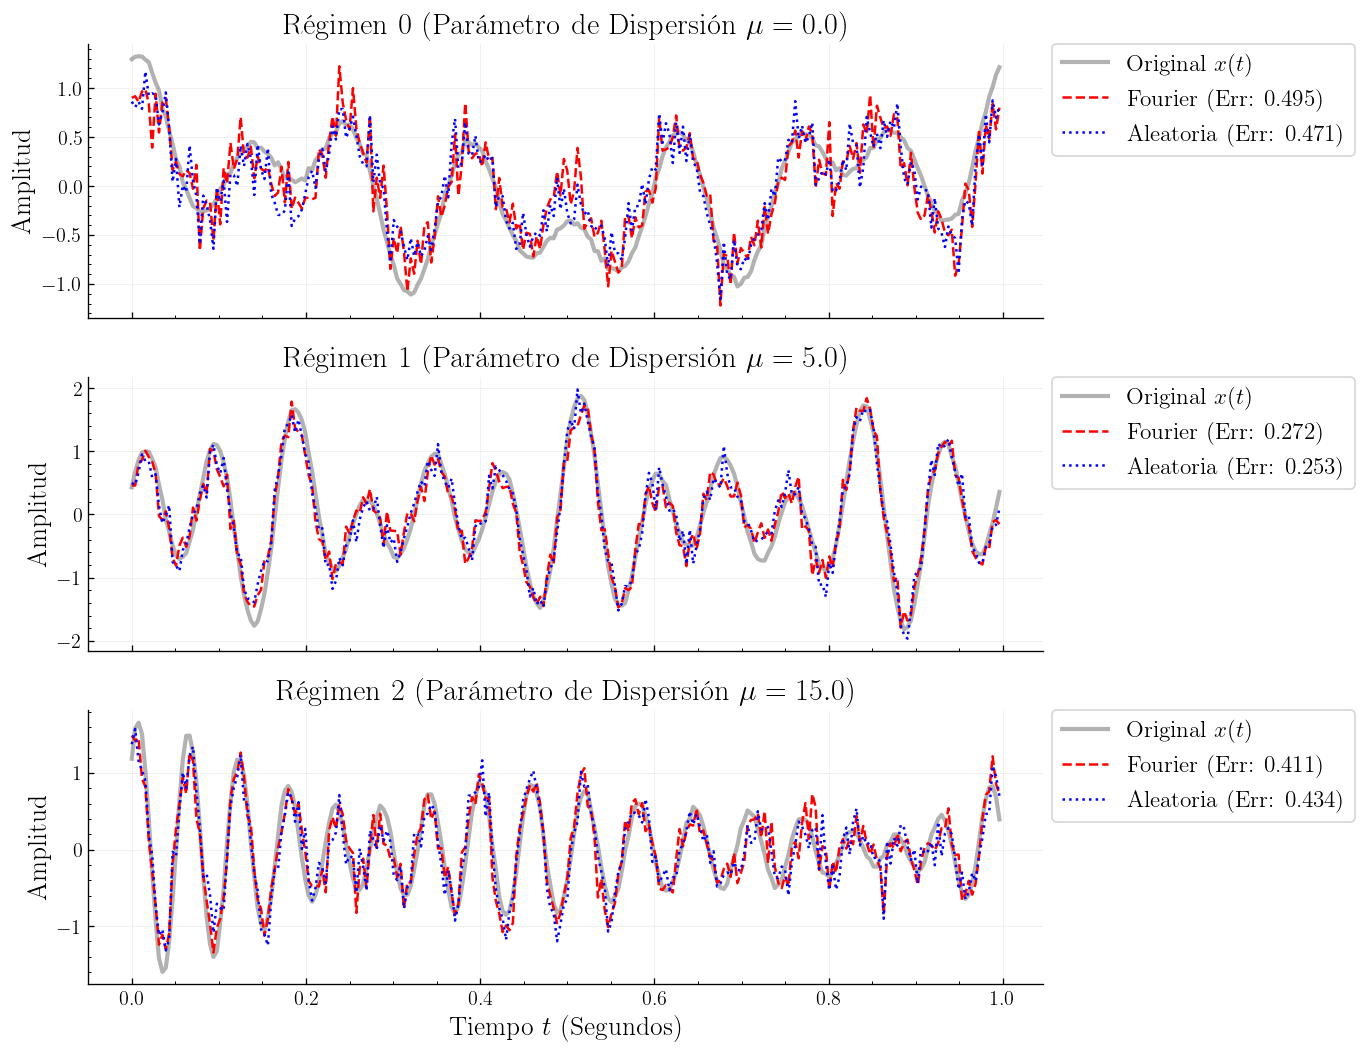

In [12]:
#AJUSTE DE HIPERPARÁMETROS PARA EXPERIMENTAR
K_exp = 50              # Aumenta esto para dar más capacidad (hidden_dim = 2 * K)
eta_exp = 0.019          # Prueba con 0.05, 0.01, 0.005
iteraciones_exp = 8000  # Despues de probar indvidualmente esta fue la mejor cantidad

# Actualizamos los valores que usará el entrenamiento
hidden_dim = 2 * K_exp
eta = eta_exp
iteraciones = iteraciones_exp

# Re-calculamos W1_fourier_init with the new K_exp
W1_fourier_init = construir_capa_fourier(n_features, K_exp)

# Codigo previamente utilizado para el entrenamiento
#Parte 1: iniciación y entrenamiento

# Semilla reproducible basada en tu ID
key = jax.random.PRNGKey(3951)
k1, k2 = jax.random.split(key)
#Error relativo
def calcular_error_relativo_lote(X_real, X_pred):
    norma_error = np.linalg.norm(X_pred - X_real, axis=1)
    norma_real = np.linalg.norm(X_real, axis=1)
    return norma_error / norma_real
params_rand = {
    'W1': jax.random.normal(k1, (hidden_dim, n_features)) * jnp.sqrt(2.0 / n_features),
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

params_four = {
    'W1': W1_fourier_init,
    'W2': jax.random.normal(k2, (n_features, hidden_dim)) * jnp.sqrt(2.0 / hidden_dim)
}

historial_loss_rand, historial_loss_four = [], []
historial_err_rand_global, historial_err_four_global = [], []
historial_err_rand_r0, historial_err_four_r0 = [], []

# Índice para Régimen 0 (Enfoque según instrucciones)
idx_regimen_foco = np.where(y_train == 0)[0]

p_rand = params_rand.copy()
p_four = params_four.copy()

print("Entrenando redes...")
for i in range(iteraciones + 1):
    p_rand = update(p_rand, X_train, eta)
    p_four = update(p_four, X_train, eta)

    loss_r = loss_fn(p_rand, X_train)
    loss_f = loss_fn(p_four, X_train)
    historial_loss_rand.append(loss_r)
    historial_loss_four.append(loss_f)

    x_hat_r_curr = np.array(forward_batch(p_rand, X_train))
    x_hat_f_curr = np.array(forward_batch(p_four, X_train))

    err_r_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_r_curr)
    err_f_individual = calcular_error_relativo_lote(np.array(X_train), x_hat_f_curr)

    historial_err_rand_global.append(np.mean(err_r_individual))
    historial_err_four_global.append(np.mean(err_f_individual))

    historial_err_rand_r0.append(np.mean(err_r_individual[idx_regimen_foco]))
    historial_err_four_r0.append(np.mean(err_f_individual[idx_regimen_foco]))

# BÚSQUEDA DE UMBRAL
def buscar_iteracion_umbral(historial, umbral):
    for idx, val in enumerate(historial):
        if val < umbral: return f"{idx} iteraciones."
    return f"No alcanzó el umbral en {iteraciones} iteraciones (Mínimo alcanzado: {min(historial):.3f})"


print("MÉTRICAS DE CONVERGENCIA GLOBAL (Error < 0.1)")
print(f"-> Inicialización Aleatoria: {buscar_iteracion_umbral(historial_err_rand_global, 0.1)}")
print(f"-> Inicialización de Fourier: {buscar_iteracion_umbral(historial_err_four_global, 0.1)}")


# VISUALIZACIÓN

# A. Pérdida Global
plt.figure(figsize=(10, 5))
plt.plot(historial_loss_rand, 'b-', label=r'$\text{Inicialización Aleatoria}$', linewidth=1.8)
plt.plot(historial_loss_four, 'r--', label=r'$\text{Inicialización Fourier (Física)}$', linewidth=1.8)
plt.yscale('log')
plt.xlabel(r'$\text{Iteraciones de Gradiente Descendente}$',)
plt.ylabel(r'$\text{Pérdida } L \text{ (MSE - Escala Log)}$')
plt.title(r'$\mathbf{\text{Evolución Global de la Función de Costo (MSE)}}$',)
plt.grid(True, which="both", ls=":")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# B. Régimen 0 (Enfoque de las instrucciones)
plt.figure(figsize=(10, 5))
plt.plot(historial_err_rand_r0, 'b-', label=r'$\text{Aleatoria (Régimen 0)}$', linewidth=1.8)
plt.plot(historial_err_four_r0, 'r--', label=r'$\text{Fourier (Régimen 0)}$', linewidth=1.8)
plt.axhline(y=0.1, color='g', linestyle=':', label=r'$\text{Umbral Crítico (0.1)}$')
plt.xlabel(r'$\text{Iteraciones}$')
plt.ylabel(r'$\text{Error Relativo Promedidado en Régimen 0}$')
plt.title(r'$\mathbf{\text{Análisis del Régimen Foco (Régimen 0: Sin Dispersión, } \mu=0.0)}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# C. Reconstrucciones finales para cada régimen
X_hat_final_rand = forward_batch(p_rand, X_train)
X_hat_final_four = forward_batch(p_four, X_train)
valores_mu = {0: "0.0", 1: "5.0", 2: "15.0"}

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

print("ERRRORES RELATIVOS FINALES DE RECONSTRUCCIÓN")

for reg in [0, 1, 2]:
    idx = np.where(y_train == reg)[0][0]
    err_f = np.linalg.norm(X_hat_final_four[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])
    err_r = np.linalg.norm(X_hat_final_rand[idx] - X_train[idx]) / np.linalg.norm(X_train[idx])

    print(f"Régimen {reg} (mu={valores_mu[reg]}): Fourier Err = {err_f:.4f} | Aleatorio Err = {err_r:.4f}")

    axs[reg].plot(t, X_train[idx], 'k-', label=r'$\text{Original } x(t)$', alpha=0.3, linewidth=2.5)
    axs[reg].plot(t, X_hat_final_four[idx], 'r--', label=r'$\text{Fourier (Err: ' + f'{err_f:.3f}' + ')}$')
    axs[reg].plot(t, X_hat_final_rand[idx], 'b:', label=r'$\text{Aleatoria (Err: ' + f'{err_r:.3f}' + ')}$')

    axs[reg].set_title(r'$\text{Régimen ' + str(reg) + r' (Parámetro de Dispersión } \mu = ' + valores_mu[reg] + r')$')
    axs[reg].set_ylabel(r'$\text{Amplitud}$')
    axs[reg].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.)
    axs[reg].grid(True)

axs[2].set_xlabel(r'$\text{Tiempo } t \text{ (Segundos)}$')
plt.tight_layout()
plt.subplots_adjust(right=0.80)
print("\n")
plt.show()

# Conclusiones
Después de experimentar con las cantidad de neuronas, iteraciones y la tasa de aprendizaje se puede concluir que aumentar las primeras 2 dismunuye el error hacercandolo a 0.3 aproximadamente para ambas inicializaciones, el cual antes con los hiperparamentros correspondientes a mi ID llegaba a 0.7 aproximadamente. Experimentando con este último código, si se baja la tasa de aprendizaje el error no disminuye (en su lugar aumenta), lo cual es diferente a lo que se esperaba. Esto no quiere decir que 0.02 es el learning rate ideal, sino que para este número de neuronas, la función que siempre se ha utilizado en esta práctica e iteraciones la mejor tasa para el error deseado es de 0.02; es decir, se requeririan más experimentos para encontrar la mejor combinación de estos valores para encontrar la que nos acerca el error al pedido (0.1), pero este ejercicio es ideal para ver como se comportan los hiperparámetros descritos con el error relativo de una red. Finalmente con este ultimo código se va a realizar la compresión para ver como se comporta la red del experimento.


ANÁLISIS DE COMPRESIÓN
K = 50
hidden_dim = 100
eta = 0.019
iteraciones = 8000

Coeficientes promedio necesarios (85% energía): 5
Compresión obtenida: 95.00%


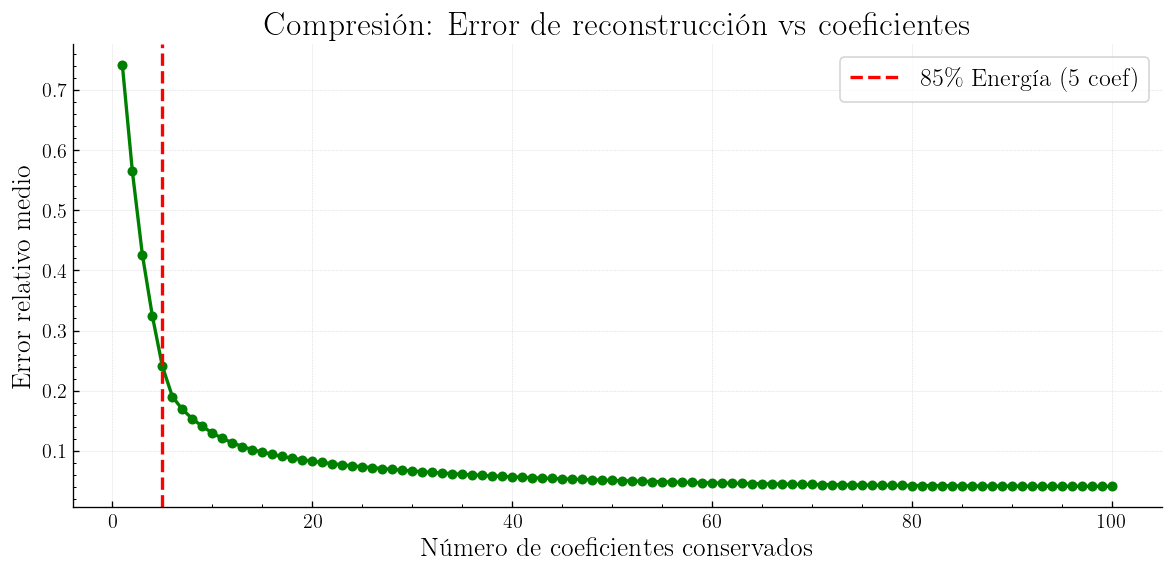

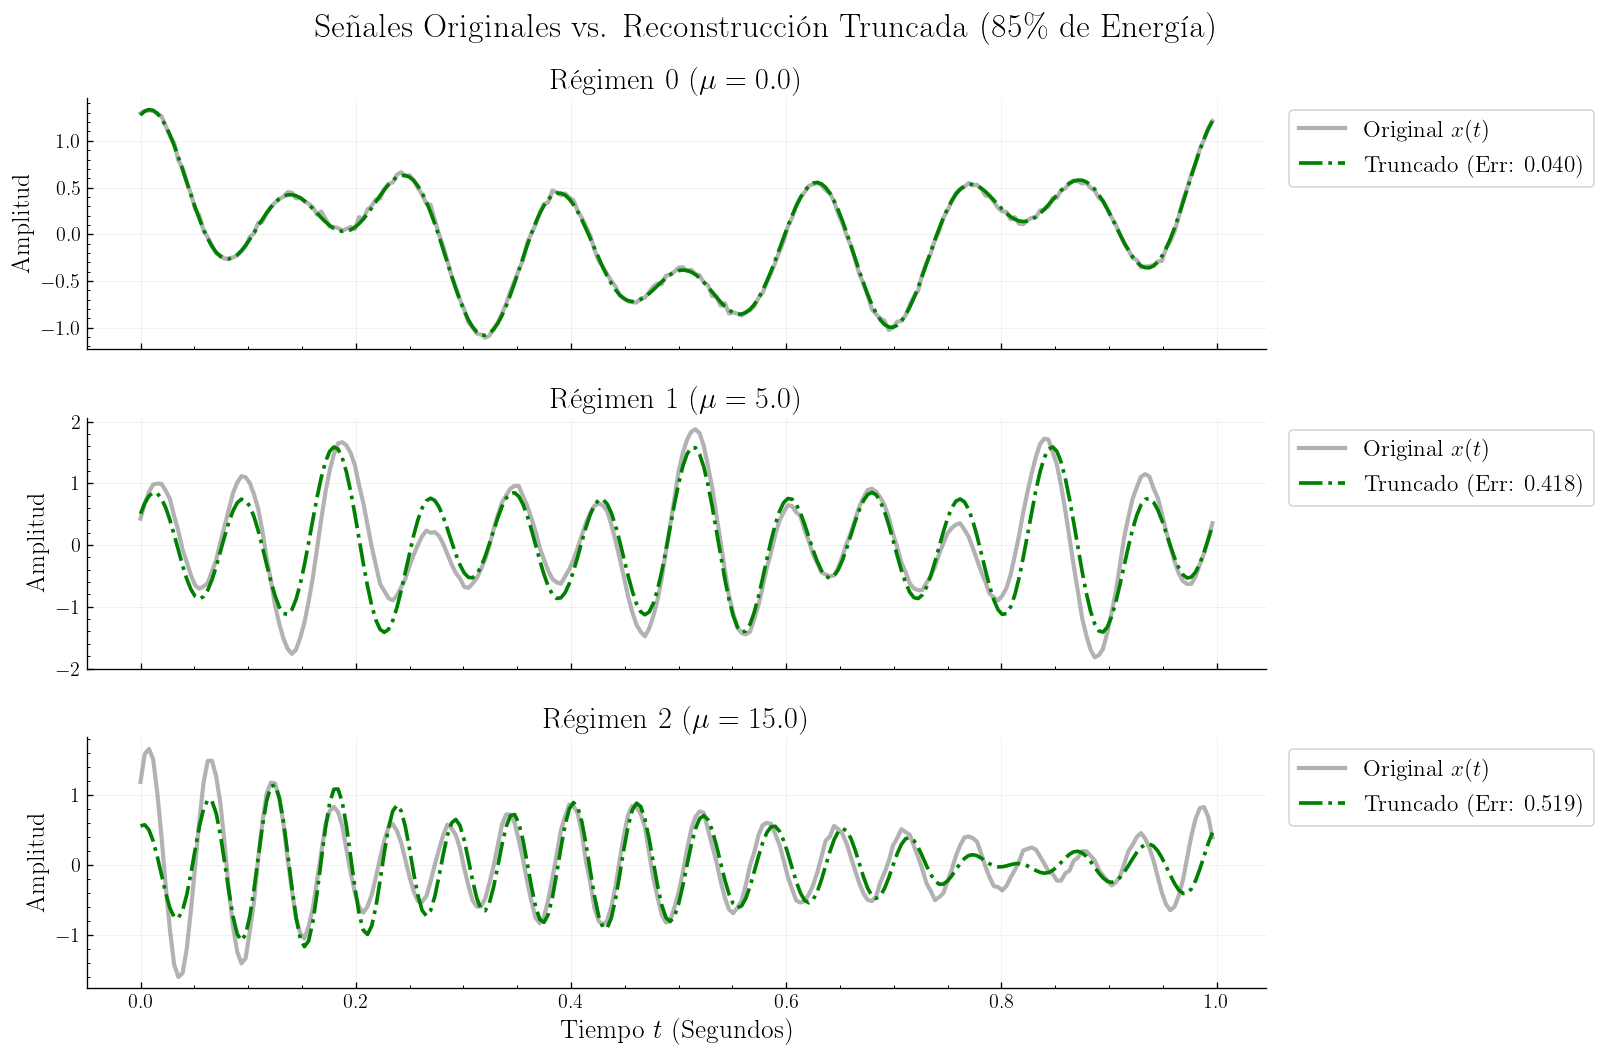

In [28]:

import numpy as np
import jax
import matplotlib.pyplot as plt


# Información del experimento


print("ANÁLISIS DE COMPRESIÓN")
print(f"K = {K_exp}")
print(f"hidden_dim = {hidden_dim}")
print(f"eta = {eta}")
print(f"iteraciones = {iteraciones}")


# Conversión de JAX -> NumPy


X_np = np.asarray(jax.device_get(X_train))
W_fourier = np.asarray(jax.device_get(W1_fourier_init))
y_np = np.asarray(jax.device_get(y_train))


# Transformada de Fourier


coeficientes_fourier = X_np @ W_fourier.T

energia_componentes = coeficientes_fourier**2

energia_ordenada = np.sort(
    energia_componentes,
    axis=1
)[:, ::-1]

energia_total = np.maximum(
    energia_ordenada.sum(axis=1, keepdims=True),
    1e-12
)

energia_relativa = (
    np.cumsum(energia_ordenada, axis=1)
    / energia_total
)


# Número de coeficientes para conservar 85%


UMBRAL = 0.85

componentes_por_senal = (
    np.argmax(
        energia_relativa >= UMBRAL,
        axis=1
    ) + 1
)

componentes_necesarias = int(
    np.ceil(
        componentes_por_senal.mean()
    )
)

print(f"\nCoeficientes promedio necesarios (85% energía): "
      f"{componentes_necesarias}")

print(f"Compresión obtenida: "
      f"{100*(1-componentes_necesarias/hidden_dim):.2f}%")


# Reconstrucción truncada


base_pinv = np.linalg.pinv(W_fourier.T)

X_reconstruido = np.zeros_like(X_np)

for i in range(X_np.shape[0]):

    coefs = coeficientes_fourier[i].copy()

    orden = np.argsort(
        energia_componentes[i]
    )[::-1]

    coefs[orden[componentes_necesarias:]] = 0

    X_reconstruido[i] = coefs @ base_pinv


# Curva Error vs Coeficientes


errores = np.zeros(hidden_dim)

for k in range(1, hidden_dim + 1):

    error_total = 0

    for i in range(X_np.shape[0]):

        coefs = coeficientes_fourier[i].copy()

        orden = np.argsort(
            energia_componentes[i]
        )[::-1]

        coefs[orden[k:]] = 0

        reconstruccion = coefs @ base_pinv

        error_total += (
            np.linalg.norm(
                reconstruccion - X_np[i]
            )
            /
            np.linalg.norm(X_np[i])
        )

    errores[k-1] = error_total / X_np.shape[0]


# GRÁFICA 1


plt.figure(figsize=(10,5))

plt.plot(
    np.arange(1, hidden_dim+1),
    errores,
    color="green",
    marker="o",
    markersize=5,
    linewidth=2
)

plt.axvline(
    componentes_necesarias,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"85\% Energía ({componentes_necesarias} coef)"
)

plt.title(
    "Compresión: Error de reconstrucción vs coeficientes",
    fontsize=20
)

plt.xlabel(
    "Número de coeficientes conservados",
    fontsize=16
)

plt.ylabel(
    "Error relativo medio",
    fontsize=16
)

plt.grid(alpha=0.3)

plt.legend(
    fontsize=15,
    loc="upper right"
)

plt.tight_layout()

plt.show()


# GRÁFICA 2


fig, axs = plt.subplots(
    3,
    1,
    figsize=(13,9),
    sharex=True
)

fig.suptitle(
    "Señales Originales vs. Reconstrucción Truncada (85\% de Energía)",
    fontsize=20,
    y=0.98
)

for reg in [0,1,2]:

    idx = np.where(y_np == reg)[0][0]

    error = (
        np.linalg.norm(
            X_reconstruido[idx]-X_np[idx]
        )
        /
        np.linalg.norm(X_np[idx])
    )

    axs[reg].plot(
        t,
        X_np[idx],
        color="gray",
        linewidth=2.5,
        alpha=0.6,
        label=r"Original $x(t)$"
    )

    axs[reg].plot(
        t,
        X_reconstruido[idx],
        color="green",
        linestyle="-.",
        linewidth=2.2,
        label=rf"Truncado (Err: {error:.3f})"
    )

    axs[reg].set_title(
        rf"Régimen {reg} ($\mu = {valores_mu[reg]}$)",
        fontsize=18
    )

    axs[reg].set_ylabel(
        "Amplitud",
        fontsize=15
    )

    axs[reg].grid(alpha=0.3)

    axs[reg].legend(
        loc="upper left",
        bbox_to_anchor=(1.01,1),
        fontsize=14
    )

axs[-1].set_xlabel(
    r"Tiempo $t$ (Segundos)",
    fontsize=16
)

plt.tight_layout()

plt.subplots_adjust(
    right=0.82,
    top=0.90
)

plt.show()